In [43]:
import pandas as pd

In [67]:
df=pd.read_csv("uber.csv")

In [68]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [70]:
df.dropna(inplace=True)

In [71]:
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'])

In [72]:
df['year']=df["pickup_datetime"].dt.year

In [73]:
df['month']=df["pickup_datetime"].dt.month

In [74]:
df['day']=df["pickup_datetime"].dt.day

In [75]:
df['day_of_week']=df['pickup_datetime'].dt.dayofweek

In [76]:
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

In [77]:
df['hour']=df['pickup_datetime'].dt.hour

In [78]:
df['minute']=df['pickup_datetime'].dt.minute

In [79]:
def time_of_day(hour):
    if 5 <= hour < 12:
        return 0
    elif 12 <= hour < 17:
        return 1
    elif 17 <= hour < 21:
        return 2
    else:
        return 3

df['time_of_day'] = df['hour'].apply(time_of_day)

In [80]:
df['is_rush_hour'] = df['hour'].apply(lambda x: 1 if (7 <= x < 9) or (16 <= x < 18) else 0)

In [81]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,day_of_week,is_weekend,hour,minute,time_of_day,is_rush_hour
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,3,0,19,52,2,0
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,4,0,20,4,2,0
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,0,0,21,45,3,0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,4,0,8,22,0,1
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,3,0,17,47,2,1


In [82]:
df.drop(columns=["key","pickup_datetime"],inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199999 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         199999 non-null  int64  
 1   fare_amount        199999 non-null  float64
 2   pickup_longitude   199999 non-null  float64
 3   pickup_latitude    199999 non-null  float64
 4   dropoff_longitude  199999 non-null  float64
 5   dropoff_latitude   199999 non-null  float64
 6   passenger_count    199999 non-null  int64  
 7   year               199999 non-null  int32  
 8   month              199999 non-null  int32  
 9   day                199999 non-null  int32  
 10  day_of_week        199999 non-null  int32  
 11  is_weekend         199999 non-null  int32  
 12  hour               199999 non-null  int32  
 13  minute             199999 non-null  int32  
 14  time_of_day        199999 non-null  int64  
 15  is_rush_hour       199999 non-null  int64  
dtypes: floa

In [83]:
q1=df.quantile(0.25)
q2=df.quantile(0.75)
iqr=q2-q1
df = df[~((df < (q1 - 1.5 * iqr)) | (df > (q2 + 1.5 * iqr))).any(axis=1)]

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 124596 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         124596 non-null  int64  
 1   fare_amount        124596 non-null  float64
 2   pickup_longitude   124596 non-null  float64
 3   pickup_latitude    124596 non-null  float64
 4   dropoff_longitude  124596 non-null  float64
 5   dropoff_latitude   124596 non-null  float64
 6   passenger_count    124596 non-null  int64  
 7   year               124596 non-null  int32  
 8   month              124596 non-null  int32  
 9   day                124596 non-null  int32  
 10  day_of_week        124596 non-null  int32  
 11  is_weekend         124596 non-null  int32  
 12  hour               124596 non-null  int32  
 13  minute             124596 non-null  int32  
 14  time_of_day        124596 non-null  int64  
 15  is_rush_hour       124596 non-null  int64  
dtypes: floa

In [85]:
X=df.drop(columns=['fare_amount'])

In [86]:
y=df['fare_amount']

In [87]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,root_mean_squared_error

In [88]:
scaler=StandardScaler()

In [89]:
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)

In [90]:
m1=LinearRegression()

In [91]:
m1.fit(xtrain,ytrain)

LinearRegression()

In [92]:
ypred1=m1.predict(xtest)

In [93]:
rmse1=root_mean_squared_error(ytest,ypred1)

In [94]:
print(rmse1)

3.8211524649012554


In [95]:
r21=r2_score(ytest,ypred1)

In [96]:
print(r21)

0.04788168938051296


In [97]:
import matplotlib.pyplot as plt

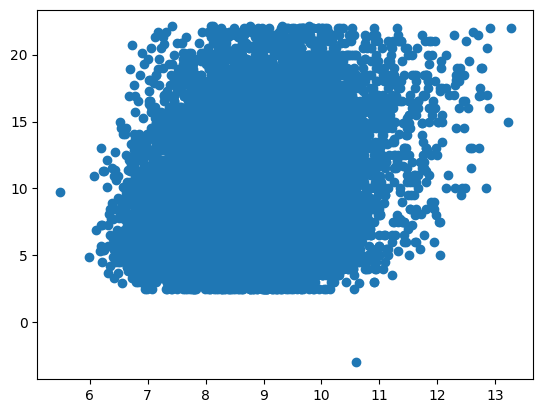

In [98]:
plt.scatter(ypred1,ytest)

In [99]:
xtrain_scaled=scaler.fit_transform(xtrain)

In [100]:
xtest_scaled=scaler.fit_transform(xtest)

In [101]:
model2=LinearRegression()

In [102]:
model2.fit(xtrain_scaled,ytrain)

LinearRegression()

In [103]:
ypred2=model2.predict(xtest_scaled)

In [104]:
rmse2=root_mean_squared_error(ytest,ypred2)

In [105]:
print(rmse2)

3.821169993689125


In [106]:
r22=r2_score(ytest,ypred2)
print(r22)

0.04787295404826586


In [107]:
def time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_of_day'] = df['hour'].apply(time_of_day)

In [108]:
df.head()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,day_of_week,is_weekend,hour,minute,time_of_day,is_rush_hour
0,24238194,7.5,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,3,0,19,52,Evening,0
1,27835199,7.7,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,4,0,20,4,Evening,0
2,44984355,12.9,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,0,0,21,45,Night,0
5,44470845,4.9,-73.969019,40.755910,-73.969019,40.755910,1,2011,2,12,5,1,2,27,Night,0
8,15822268,9.7,-73.975187,40.745767,-74.002720,40.743537,1,2012,2,17,4,0,9,32,Morning,0


## Using MinMax scaler

In [109]:
from sklearn.preprocessing import MinMaxScaler

In [110]:
m_scaler=MinMaxScaler()

In [111]:
xtrain_min=m_scaler.fit_transform(xtrain)

In [112]:
xtest_min=m_scaler.fit_transform(xtest)

In [113]:
m3=LinearRegression()

In [114]:
m3.fit(xtrain_min,ytrain)

LinearRegression()

In [115]:
ypred3=m3.predict(xtest_min)

In [117]:
rmse3=root_mean_squared_error(ytest,ypred3)
print(rmse3)

3.822063519344007


In [118]:
r23=r2_score(ytest,ypred3)
print(r23)

0.047427619550460265
